## Evaluación de solicitud de crédito bancario

### Ficha PEAS
| Elemento | Descripción |
|---|---|
| **Percepción (S)** | `ingreso_mensual` (S/), `monto_solicitado` (S/), `tiene_historial_moroso` (Boolean) |
| **Acciones (A)** | "aprobar", "aprobar con condiciones", "rechazar" |
| **Entorno (E)** | Sistema bancario automatizado de evaluación de riesgo crediticio |
| **Objetivo** | Maximizar la colocación de créditos seguros minimizando el riesgo de impago |
| **Medida de Desempeño (P)** | Tasa de retorno de capital, bajo porcentaje de morosidad y tiempo de respuesta |

### Justificación de las reglas
Las reglas priorizan la sostenibilidad financiera del banco al evaluar la relación entre el monto solicitado y el ingreso mensual (`relacion = monto / ingreso`). Una relación inferior o igual a 0.5 con historial limpio representa bajo riesgo y se aprueba directamente. Si existe historial moroso, solo se aprueban montos pequeños (relación <= 0.3) con condiciones estrictas, mientras que cualquier solicitud que supere la capacidad de pago (relación > 1.0) o combine morosidad con endeudamiento alto es rechazada inmediatamente.

In [4]:
### Código
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    """
    Evaluación automática de solicitud de crédito bancario.
    Retorna tupla: (accion, motivo)
    """
    if ingreso_mensual <= 0:
        return ("rechazar", "ingreso mensual inválido o menor igual a cero")
    
    relacion = monto_solicitado / ingreso_mensual
    
    if tiene_historial_moroso:
        if relacion <= 0.3:
            return ("aprobar con condiciones", f"historial moroso detectado, pero relación monto/ingreso es baja ({relacion:.2f} <= 0.3)")
        else:
            return ("rechazar", f"relación monto/ingreso de {relacion:.2f} mayor a 0.3 con historial moroso registrado")
    else:
        if relacion <= 0.5:
            return ("aprobar", f"buen historial crediticio y relación monto/ingreso adecuada ({relacion:.2f} <= 0.5)")
        elif relacion <= 1.0:
            return ("aprobar con condiciones", f"buen historial pero relación monto/ingreso moderada ({relacion:.2f} entre 0.5 y 1.0)")
        else:
            return ("rechazar", f"relación monto/ingreso excesiva ({relacion:.2f} > 1.0) supera capacidad de pago")

In [5]:
### Simulación y pruebas
casos_prueba_credito = [
    (5000, 2000, False),  # Relación 0.40 -> Aprobar
    (4000, 2000, False),  # Relación 0.50 (Caso Borde) -> Aprobar
    (4000, 3000, False),  # Relación 0.75 -> Aprobar con condiciones
    (3000, 4500, False),  # Relación 1.50 -> Rechazar
    (5000, 1000, True),   # Relación 0.20 -> Aprobar con condiciones
    (5000, 2500, True)    # Relación 0.50 -> Rechazar por morosidad
]

print("==========================================================================")
print("              EVALUACIÓN DE CASOS DE PRUEBA DE CRÉDITO                    ")
print("==========================================================================")
for ingreso, monto, moroso in casos_prueba_credito:
    accion, motivo = agente_credito(ingreso, monto, moroso)
    print(f"Ingreso: S/{ingreso:5d} | Monto: S/{monto:5d} | Moroso: {str(moroso):5s} -> Decisión: {accion.upper()}")
    print(f"   Motivo: {motivo}\n")

              EVALUACIÓN DE CASOS DE PRUEBA DE CRÉDITO                    
Ingreso: S/ 5000 | Monto: S/ 2000 | Moroso: False -> Decisión: APROBAR
   Motivo: buen historial crediticio y relación monto/ingreso adecuada (0.40 <= 0.5)

Ingreso: S/ 4000 | Monto: S/ 2000 | Moroso: False -> Decisión: APROBAR
   Motivo: buen historial crediticio y relación monto/ingreso adecuada (0.50 <= 0.5)

Ingreso: S/ 4000 | Monto: S/ 3000 | Moroso: False -> Decisión: APROBAR CON CONDICIONES
   Motivo: buen historial pero relación monto/ingreso moderada (0.75 entre 0.5 y 1.0)

Ingreso: S/ 3000 | Monto: S/ 4500 | Moroso: False -> Decisión: RECHAZAR
   Motivo: relación monto/ingreso excesiva (1.50 > 1.0) supera capacidad de pago

Ingreso: S/ 5000 | Monto: S/ 1000 | Moroso: True  -> Decisión: APROBAR CON CONDICIONES
   Motivo: historial moroso detectado, pero relación monto/ingreso es baja (0.20 <= 0.3)

Ingreso: S/ 5000 | Monto: S/ 2500 | Moroso: True  -> Decisión: RECHAZAR
   Motivo: relación monto/ingreso 

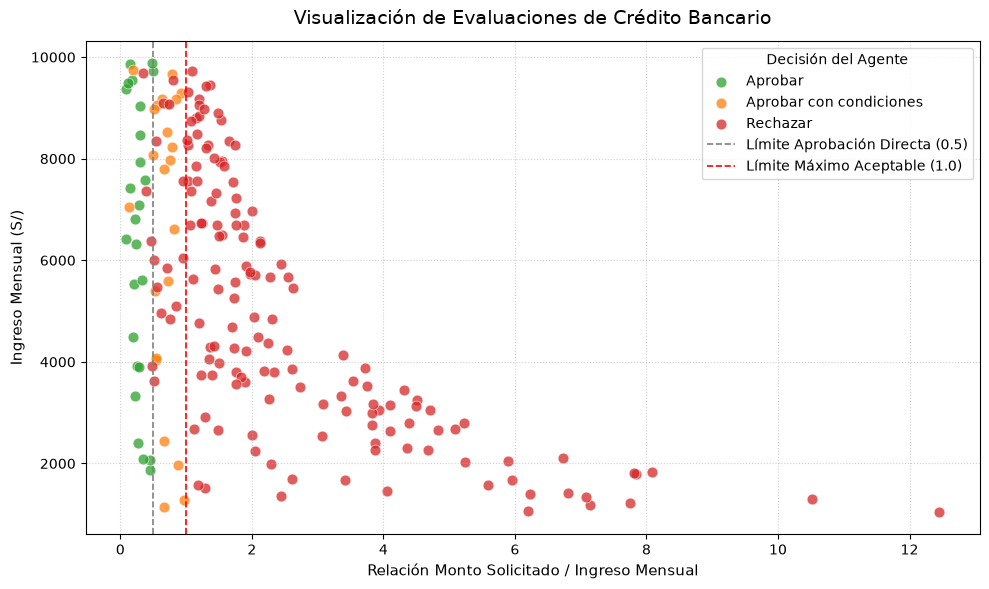

In [6]:
### Visualización
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n_solicitudes = 200

ingresos = np.random.uniform(1000, 10000, n_solicitudes)
montos = np.random.uniform(500, 15000, n_solicitudes)
morosos = np.random.choice([True, False], size=n_solicitudes, p=[0.3, 0.7])

acciones = []
relaciones = []

for ing, mon, mor in zip(ingresos, montos, morosos):
    accion, motivo = agente_credito(ing, mon, mor)
    acciones.append(accion)
    relaciones.append(mon / ing)

plt.figure(figsize=(10, 6))
colores = {
    "aprobar": "#2ca02c", 
    "aprobar con condiciones": "#ff7f0e", 
    "rechazar": "#d62728"
}

for decision, color in colores.items():
    mask = [a == decision for a in acciones]
    plt.scatter(
        np.array(relaciones)[mask], 
        ingresos[mask], 
        c=color, 
        label=decision.capitalize(), 
        alpha=0.75, 
        edgecolors='white', 
        linewidths=0.5,
        s=60
    )

plt.axvline(x=0.5, color='gray', linestyle='--', linewidth=1.2, label='Límite Aprobación Directa (0.5)')
plt.axvline(x=1.0, color='red', linestyle='--', linewidth=1.2, label='Límite Máximo Aceptable (1.0)')

plt.title("Visualización de Evaluaciones de Crédito Bancario", fontsize=14, pad=12)
plt.xlabel("Relación Monto Solicitado / Ingreso Mensual", fontsize=11)
plt.ylabel("Ingreso Mensual (S/)", fontsize=11)
plt.legend(title="Decisión del Agente", loc="upper right")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()